In [1]:
import torch


print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

Torch: 2.1.2+cu121
CUDA available: True


device(type='cuda')

In [2]:
from pathlib import Path


# paths and settings
MESH_OBJ_PATH = "data/chair_model/model_normalized.obj"
STYLE_IMAGE_PATH = "data/styles/scream.jpg"

OUTPUT_DIR = Path("outputs_uv_texture_style")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 256
DIST = 1.2
ELEV = 20.0

EVAL_AZIMS = [0, 45, 90, 135, 180, 225, 270, 315]

NUM_ITERS = 1000
VIEWS_PER_ITER = 4
LR = 0.05
LOG_EVERY = 50

W_STYLE = 1500.0
W_CONTENT = 0.0
W_COLOR = 0.0
W_TV = 0.001

BASELINE_2D_ITERS = 200
BASELINE_2D_LR = 0.04

SEED = 42

In [3]:
import random
import numpy as np


# seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [4]:
import os


print("OBJ exists:", os.path.exists(MESH_OBJ_PATH))
print("Style exists:", os.path.exists(STYLE_IMAGE_PATH))

print("\nChair model files:")
print(os.listdir("data/chair_model"))

print("\nTexture folder:")
print(os.listdir("data/chair_model/untitled"))

OBJ exists: True
Style exists: True

Chair model files:
['untitled', 'model_normalized.json', 'model_normalized.mtl', 'model_normalized.obj', 'model_normalized.solid.binvox', 'model_normalized.surface.binvox']

Texture folder:
['texture.jpg']


In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T


# functions for images
def load_image_as_tensor(path, image_size=256, device="cpu"):
    image = Image.open(path).convert("RGB")
    
    transform = T.Compose([
        T.Resize(image_size),
        T.CenterCrop(image_size),
        T.ToTensor(),
    ])
    
    tensor = transform(image).unsqueeze(0).to(device)
    return tensor


def tensor_to_pil(x):
    if x.dim() == 4:
        x = x[0]
    
    x = x.detach().cpu().clamp(0, 1)
    arr = (x.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(arr)


def show_tensor_image(x, title=None, figsize=(4, 4)):
    img = tensor_to_pil(x)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


def save_tensor_image(x, path):
    img = tensor_to_pil(x)
    img.save(path)

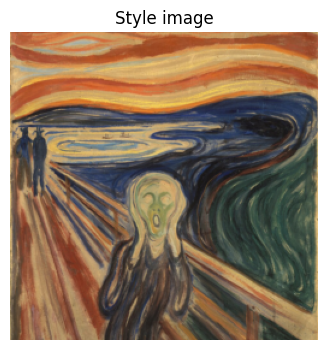

In [6]:
style_img = load_image_as_tensor(STYLE_IMAGE_PATH, IMAGE_SIZE, device)
show_tensor_image(style_img, "Style image")

In [7]:
from pytorch3d.io import load_objs_as_meshes


# loading a 3D model
mesh = load_objs_as_meshes(
    [MESH_OBJ_PATH],
    device=device,
    load_textures=True,
)

print(mesh)

if mesh.textures is None:
    raise ValueError("У меша нет текстуры. Нужен OBJ + MTL + texture image.")

if not hasattr(mesh.textures, "maps_padded"):
    raise ValueError("Текстура не является TexturesUV. Нужна UV texture map.")

initial_texture = mesh.textures.maps_padded()[0].detach().clone().to(device)

print("Initial texture shape [H, W, C]:", initial_texture.shape)
print("Texture min:", initial_texture.min().item())
print("Texture max:", initial_texture.max().item())

Initial texture shape [H, W, C]: torch.Size([256, 256, 3])
Texture min: 0.07450980693101883
Texture max: 0.686274528503418


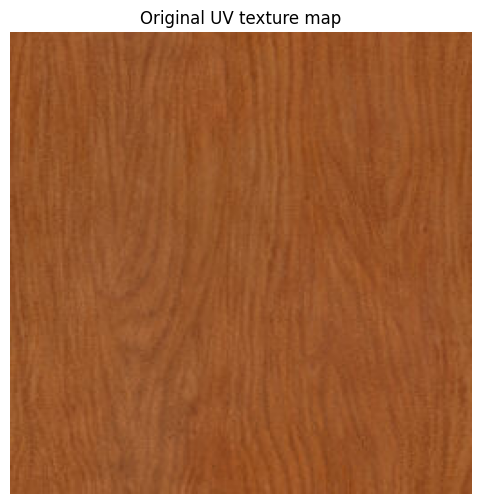

In [8]:
# show original UV texture
plt.figure(figsize=(6, 6))
plt.imshow(initial_texture.detach().cpu().clamp(0, 1).numpy())
plt.axis("off")
plt.title("Original UV texture map")
plt.show()

In [9]:
from pytorch3d.structures import Meshes
from pytorch3d.renderer import AmbientLights
from pytorch3d.renderer import (
    look_at_view_transform,
    FoVPerspectiveCameras,
    RasterizationSettings,
    PointLights,
    BlendParams,
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    TexturesUV
)


# Renderer
def make_renderer(image_size=256, dist=2.7, elev=20.0, azim=0.0, device="cpu"):
    R, T_cam = look_at_view_transform(
        dist=dist,
        elev=elev,
        azim=azim,
        device=device,
    )

    cameras = FoVPerspectiveCameras(
        device=device,
        R=R,
        T=T_cam,
    )

    raster_settings = RasterizationSettings(
        image_size=image_size,
        blur_radius=0.0,
        faces_per_pixel=1,
        cull_backfaces=False,
    )

    lights = AmbientLights(device=device)

    blend_params = BlendParams(
        background_color=(1.0, 1.0, 1.0)
    )

    renderer = MeshRenderer(
        rasterizer=MeshRasterizer(
            cameras=cameras,
            raster_settings=raster_settings,
        ),
        shader=SoftPhongShader(
            device=device,
            cameras=cameras,
            lights=lights,
            blend_params=blend_params,
        ),
    )

    return renderer


def make_mesh_with_texture(base_mesh, texture_map):
    textures = TexturesUV(
        maps=texture_map.unsqueeze(0),
        faces_uvs=base_mesh.textures.faces_uvs_list(),
        verts_uvs=base_mesh.textures.verts_uvs_list(),
    )
    
    new_mesh = Meshes(
        verts=base_mesh.verts_list(),
        faces=base_mesh.faces_list(),
        textures=textures,
    )
    
    return new_mesh

In [10]:
# render RGB + alpha
def render_mesh_rgba(base_mesh, texture_map, azim=0.0, elev=20.0, dist=2.7, image_size=256):
    renderer = make_renderer(
        image_size=image_size,
        dist=dist,
        elev=elev,
        azim=azim,
        device=device,
    )
    
    render_mesh_obj = make_mesh_with_texture(base_mesh, texture_map)
    image = renderer(render_mesh_obj)  # [1, H, W, 4]
    
    rgb = image[..., :3].permute(0, 3, 1, 2).contiguous()
    alpha = image[..., 3:4].permute(0, 3, 1, 2).contiguous()
    
    return rgb.clamp(0, 1), alpha.clamp(0, 1)


def render_mesh(base_mesh, texture_map, azim=0.0, elev=20.0, dist=2.7, image_size=256):
    rgb, alpha = render_mesh_rgba(
        base_mesh,
        texture_map,
        azim=azim,
        elev=elev,
        dist=dist,
        image_size=image_size,
    )
    
    return rgb

In [11]:
import torch.nn.functional as F


# foreground crop for alpha mask
def crop_foreground_tensor(rgb, alpha, out_size=256, padding=35):
    mask = alpha[0, 0].detach().cpu() > 0.05
    
    if mask.sum() == 0:
        return rgb
    
    ys, xs = torch.where(mask)
    
    y1 = max(int(ys.min()) - padding, 0)
    y2 = min(int(ys.max()) + padding, rgb.shape[2] - 1)
    x1 = max(int(xs.min()) - padding, 0)
    x2 = min(int(xs.max()) + padding, rgb.shape[3] - 1)
    
    crop = rgb[:, :, y1:y2 + 1, x1:x2 + 1]
    
    crop = F.interpolate(
        crop,
        size=(out_size, out_size),
        mode="bilinear",
        align_corners=False,
    )
    
    return crop.clamp(0, 1)

In [12]:
import math


# Visualization of renderers
def render_view_grid(base_mesh, texture_map, azims, title, image_size=256, elev=20.0, dist=2.7):
    n = len(azims)
    cols = min(4, n)
    rows = math.ceil(n / cols)
    
    plt.figure(figsize=(4 * cols, 4 * rows))
    
    for i, azim in enumerate(azims):
        with torch.no_grad():
            img = render_mesh(
                base_mesh,
                texture_map,
                azim=azim,
                elev=elev,
                dist=dist,
                image_size=image_size,
            )
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(tensor_to_pil(img))
        plt.axis("off")
        plt.title(f"azim={azim}°")
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

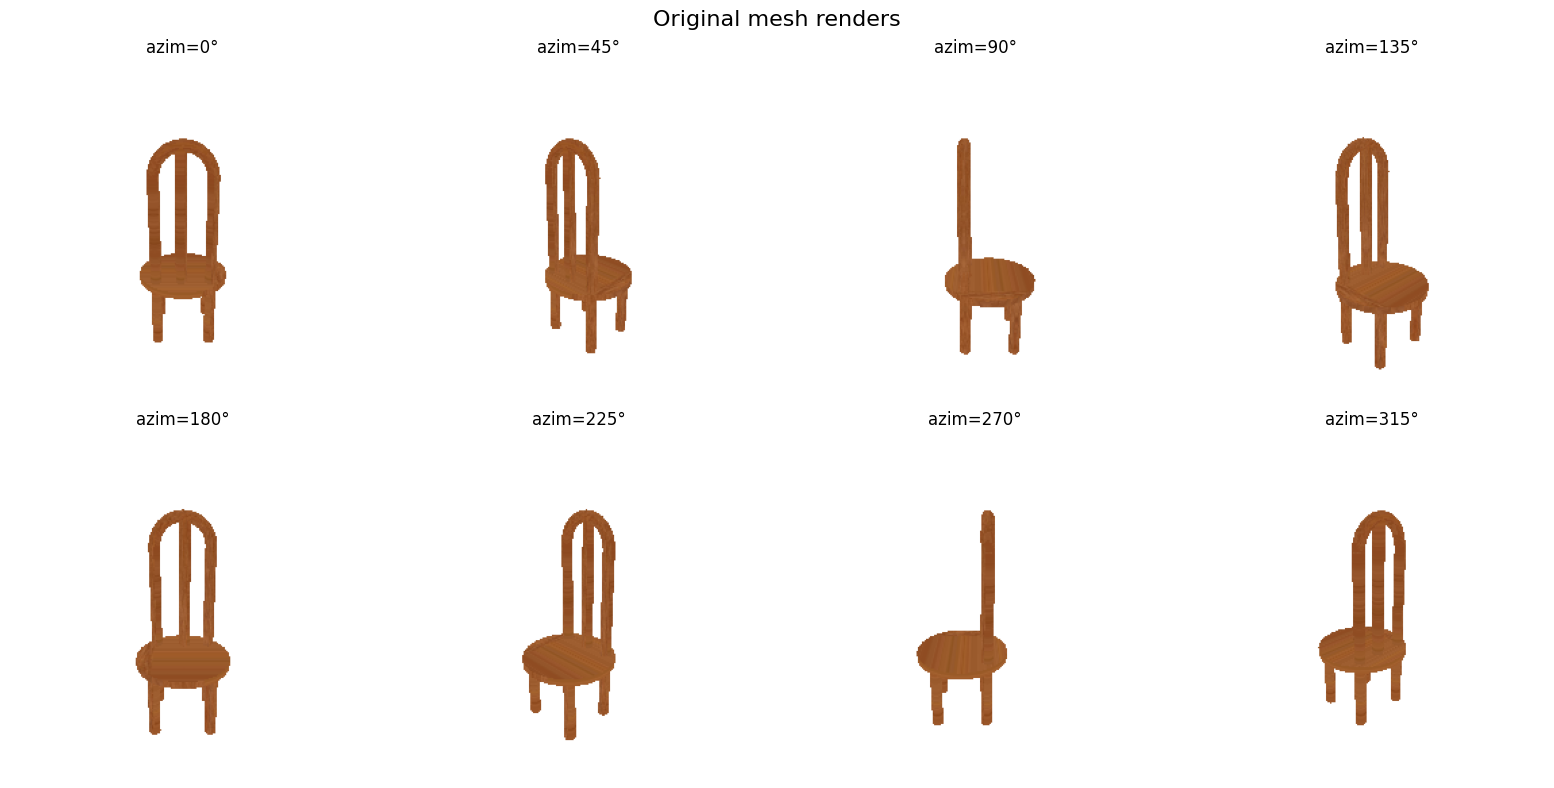

In [13]:
# check the original mesh
render_view_grid(
    mesh,
    initial_texture,
    EVAL_AZIMS,
    title="Original mesh renders",
    image_size=IMAGE_SIZE,
    elev=ELEV,
    dist=DIST,
)

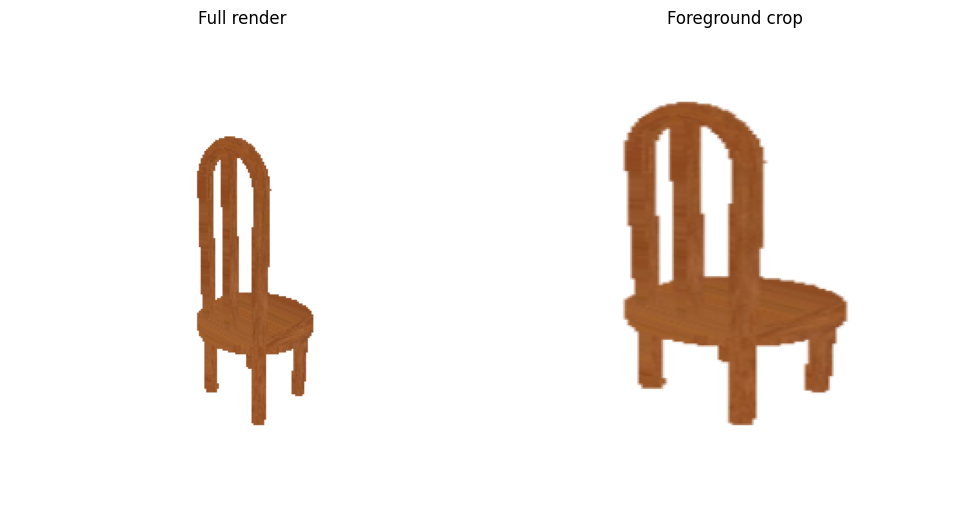

In [14]:
# check the crop of an object
with torch.no_grad():
    rgb, alpha = render_mesh_rgba(
        mesh,
        initial_texture,
        azim=45,
        elev=ELEV,
        dist=DIST,
        image_size=IMAGE_SIZE,
    )

    crop = crop_foreground_tensor(
        rgb,
        alpha,
        out_size=IMAGE_SIZE,
        padding=35,
    )

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(tensor_to_pil(rgb))
plt.axis("off")
plt.title("Full render")

plt.subplot(1, 2, 2)
plt.imshow(tensor_to_pil(crop))
plt.axis("off")
plt.title("Foreground crop")

plt.tight_layout()
plt.show()

In [15]:
from torchvision import models
import torch.nn as nn


# VGG feature extractor
class VGGFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        
        weights = models.VGG19_Weights.IMAGENET1K_V1
        vgg = models.vgg19(weights=weights).features.eval()
        
        for p in vgg.parameters():
            p.requires_grad = False
        
        self.vgg = vgg
        
        self.layer_names = {
            "1": "relu1_1",
            "6": "relu2_1",
            "11": "relu3_1",
            "20": "relu4_1",
            "21": "relu4_2",
            "29": "relu5_1",
        }
        
        self.style_layers = [
            "relu1_1",
            "relu2_1",
            "relu3_1",
            "relu4_1",
            "relu5_1",
        ]
        
        self.content_layer = "relu4_2"
        
        self.register_buffer(
            "mean",
            torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        )
        self.register_buffer(
            "std",
            torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        )
    
    def normalize(self, x):
        return (x - self.mean) / self.std
    
    def forward(self, x):
        x = self.normalize(x)
        features = {}
        
        for name, layer in self.vgg._modules.items():
            x = layer(x)
            if name in self.layer_names:
                features[self.layer_names[name]] = x
        
        return features


def gram_matrix(feat):
    B, C, H, W = feat.shape
    f = feat.view(B, C, H * W)
    gram = torch.bmm(f, f.transpose(1, 2))
    gram = gram / (C * H * W)
    return gram


vgg_extractor = VGGFeatureExtractor().to(device).eval()

In [16]:
from torch.nn import functional as F


# Loss functions
def compute_style_targets(style_img, extractor):
    with torch.no_grad():
        feats = extractor(style_img)
        style_targets = {}
        
        for layer in extractor.style_layers:
            style_targets[layer] = gram_matrix(feats[layer])
    
    return style_targets


def style_loss_fn(img, style_targets, extractor):
    feats = extractor(img)
    loss = 0.0
    
    for layer in extractor.style_layers:
        gram = gram_matrix(feats[layer])
        loss = loss + F.mse_loss(gram, style_targets[layer])
    
    return loss


def content_loss_fn(current_img, target_img, extractor):
    current_feats = extractor(current_img)
    
    with torch.no_grad():
        target_feats = extractor(target_img)
    
    layer = extractor.content_layer
    return F.mse_loss(current_feats[layer], target_feats[layer])


def color_luminance_loss_fn(current_img, target_img):
    current_low = F.avg_pool2d(current_img, kernel_size=16, stride=16)
    target_low = F.avg_pool2d(target_img, kernel_size=16, stride=16)
    return F.mse_loss(current_low, target_low)


def tv_loss_texture(texture_map):
    dh = torch.abs(texture_map[1:, :, :] - texture_map[:-1, :, :]).mean()
    dw = torch.abs(texture_map[:, 1:, :] - texture_map[:, :-1, :]).mean()
    return dh + dw


def img_tv_loss(img):
    dh = torch.abs(img[:, :, 1:, :] - img[:, :, :-1, :]).mean()
    dw = torch.abs(img[:, :, :, 1:] - img[:, :, :, :-1]).mean()
    return dh + dw

In [17]:
# compute style targets
style_targets = compute_style_targets(style_img, vgg_extractor)

print("Style targets prepared:")
for k, v in style_targets.items():
    print(k, v.shape)

Style targets prepared:
relu1_1 torch.Size([1, 64, 64])
relu2_1 torch.Size([1, 128, 128])
relu3_1 torch.Size([1, 256, 256])
relu4_1 torch.Size([1, 512, 512])
relu5_1 torch.Size([1, 512, 512])


In [18]:
# Preparing UV map optimization
def to_logits(x, eps=1e-5):
    x = x.clamp(eps, 1.0 - eps)
    return torch.log(x / (1.0 - x))


H, W, C = initial_texture.shape

style_texture_init = F.interpolate(
    style_img,
    size=(H, W),
    mode="bilinear",
    align_corners=False,
)

style_texture_init = style_texture_init[0].permute(1, 2, 0).contiguous()

mixed_init = 0.2 * initial_texture + 0.8 * style_texture_init

texture_logits = nn.Parameter(
    to_logits(mixed_init).detach().clone()
)

optimizer = torch.optim.Adam([texture_logits], lr=LR)

history = {
    "total": [],
    "style": [],
    "content": [],
    "color": [],
    "tv": [],
}

preview_dir = OUTPUT_DIR / "previews"
preview_dir.mkdir(exist_ok=True)

print("Optimization is ready with style-based texture initialization.")

Optimization is ready with style-based texture initialization.


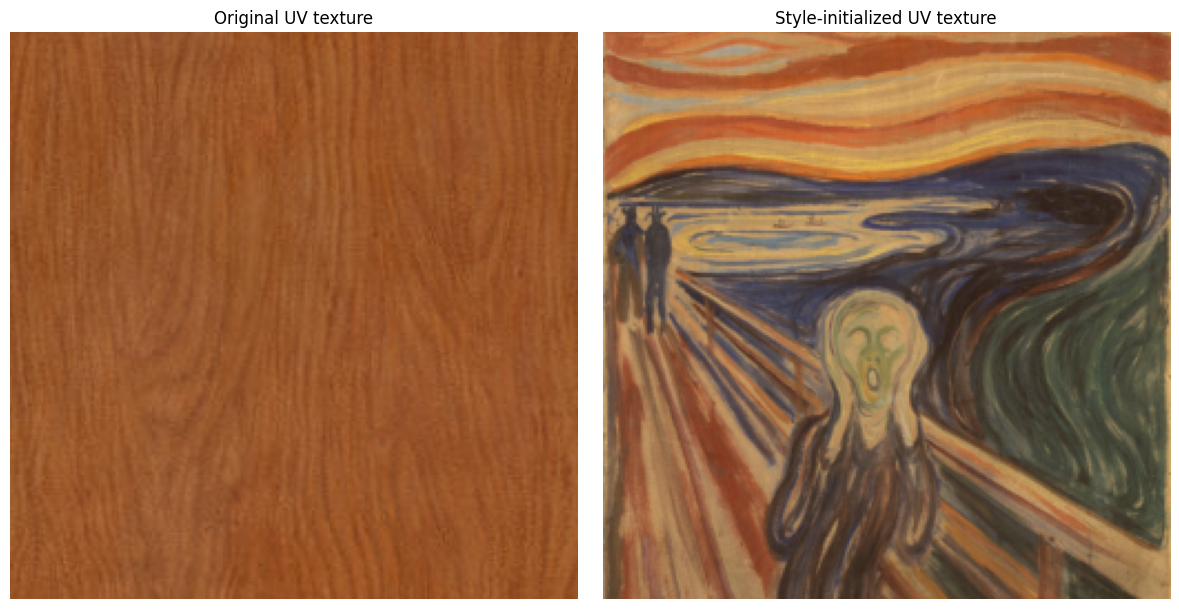

In [19]:
with torch.no_grad():
    init_texture_preview = torch.sigmoid(texture_logits)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(initial_texture.detach().cpu().clamp(0, 1).numpy())
plt.axis("off")
plt.title("Original UV texture")

plt.subplot(1, 2, 2)
plt.imshow(init_texture_preview.detach().cpu().clamp(0, 1).numpy())
plt.axis("off")
plt.title("Style-initialized UV texture")

plt.tight_layout()
plt.show()

In [20]:
FIXED_AZIMS = [0, 45, 90, 135, 180, 225, 270, 315]

FIXED_ELEVS_HIGH = [40, 50, 45, 40, 40, 50, 45, 40]

print("Fixed azims:", FIXED_AZIMS)
print("Fixed elevs:", FIXED_ELEVS_HIGH)

Fixed azims: [0, 45, 90, 135, 180, 225, 270, 315]
Fixed elevs: [40, 50, 45, 40, 40, 50, 45, 40]


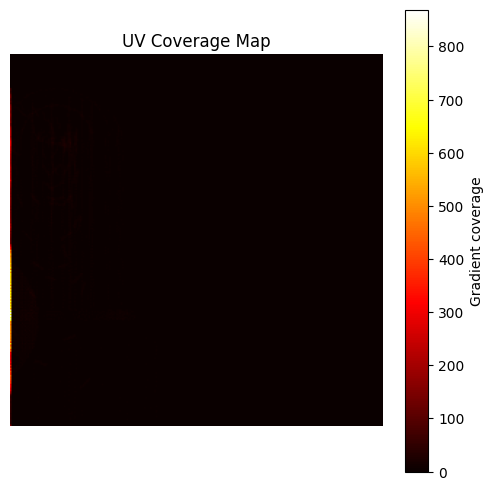

Покрыто пикселей UV-карты: 18.9%


In [21]:
# UV coverage map
def compute_uv_coverage(base_mesh, azims, elevs, image_size=256):
    H, W, _ = base_mesh.textures.maps_padded()[0].shape
    coverage = torch.zeros(H, W, device=device)

    test_tex = torch.ones(H, W, 3, device=device, requires_grad=True)

    for azim, elev in zip(azims, elevs):
        rgb, alpha = render_mesh_rgba(
            base_mesh,
            test_tex,
            azim=float(azim),
            elev=float(elev),
            dist=DIST,
            image_size=image_size,
        )

        rgb.sum().backward()

        with torch.no_grad():
            if test_tex.grad is not None:
                coverage += test_tex.grad.abs().sum(-1)
                test_tex.grad.zero_()

    return coverage.detach().cpu()


coverage = compute_uv_coverage(
    mesh,
    FIXED_AZIMS,
    FIXED_ELEVS_HIGH,
    image_size=IMAGE_SIZE,
)

plt.figure(figsize=(6, 6))
plt.imshow(coverage.numpy(), cmap="hot")
plt.colorbar(label="Gradient coverage")
plt.title("UV Coverage Map")
plt.axis("off")
plt.show()

covered_ratio = (coverage > 0).float().mean().item()
print(f"Покрыто пикселей UV-карты: {covered_ratio:.1%}")

In [22]:
import time
from tqdm import tqdm


# UV texture training
for it in tqdm(range(1, NUM_ITERS + 1)):
    optimizer.zero_grad()

    texture_map = torch.sigmoid(texture_logits)

    total_style = 0.0

    if it % 8 == 0:
        azims = FIXED_AZIMS
        elevs = FIXED_ELEVS_HIGH
    else:
        azims = np.random.uniform(0, 360, size=VIEWS_PER_ITER)
        elevs = np.random.uniform(10, 50, size=VIEWS_PER_ITER)

    n_views = len(azims)

    for azim, elev in zip(azims, elevs):
        current_rgb, current_alpha = render_mesh_rgba(
            mesh,
            texture_map,
            azim=float(azim),
            elev=float(elev),
            dist=DIST,
            image_size=IMAGE_SIZE,
        )

        current_crop = crop_foreground_tensor(
            current_rgb,
            current_alpha,
            out_size=IMAGE_SIZE,
            padding=35,
        )

        total_style = total_style + style_loss_fn(
            current_crop,
            style_targets,
            vgg_extractor,
        )

    total_style = total_style / n_views
    total_tv = tv_loss_texture(texture_map)

    loss = W_STYLE * total_style + W_TV * total_tv

    loss.backward()

    torch.nn.utils.clip_grad_norm_([texture_logits], max_norm=1.0)

    optimizer.step()

    history["total"].append(loss.item())
    history["style"].append(total_style.item())
    history["content"].append(0.0)
    history["color"].append(0.0)
    history["tv"].append(total_tv.item())

    if it % LOG_EVERY == 0 or it == 1:
        print(
            f"iter={it:04d} | "
            f"loss={loss.item():.6e} | "
            f"style={total_style.item():.6e} | "
            f"tv={total_tv.item():.6e}"
        )

        with torch.no_grad():
            preview_tex = torch.sigmoid(texture_logits)
            preview_img = render_mesh(
                mesh,
                preview_tex,
                azim=45,
                elev=ELEV,
                dist=DIST,
                image_size=IMAGE_SIZE,
            )
            save_tensor_image(preview_img, preview_dir / f"preview_{it:04d}.png")

styled_texture = torch.sigmoid(texture_logits).detach()

print("Optimization finished.")

  0%|          | 2/1000 [00:00<05:35,  2.98it/s]

iter=0001 | loss=3.119519e-01 | style=2.079334e-04 | tv=5.179380e-02


  5%|▌         | 51/1000 [00:10<03:08,  5.03it/s]

iter=0050 | loss=2.016435e-01 | style=1.343926e-04 | tv=5.449755e-02


 10%|█         | 100/1000 [00:24<02:58,  5.04it/s]

...

iter=0900 | loss=1.933080e-01 | style=1.288122e-04 | tv=8.966069e-02


 95%|█████████▌| 950/1000 [03:35<00:10,  4.81it/s]

iter=0950 | loss=2.026771e-01 | style=1.350581e-04 | tv=9.003084e-02


100%|██████████| 1000/1000 [03:45<00:00,  4.43it/s]

iter=1000 | loss=1.873156e-01 | style=1.248168e-04 | tv=9.040176e-02
Optimization finished.


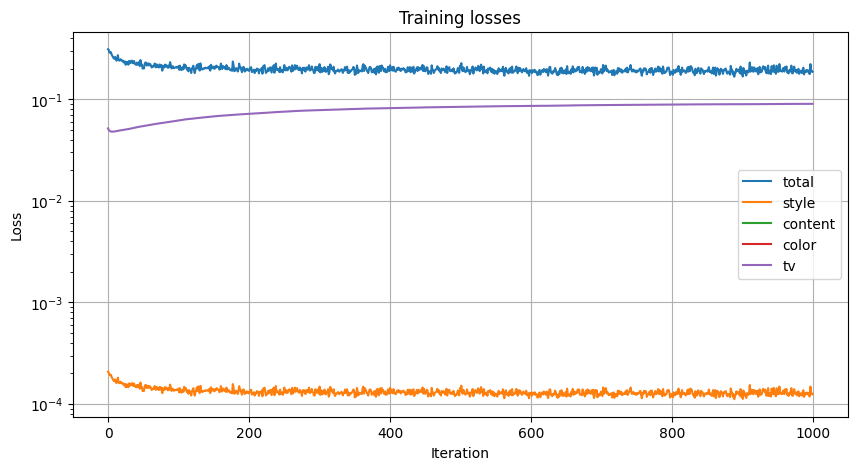

In [23]:
# Loss curves
plt.figure(figsize=(10, 5))

plt.plot(history["total"], label="total")
plt.plot(history["style"], label="style")
plt.plot(history["content"], label="content")
plt.plot(history["color"], label="color")
plt.plot(history["tv"], label="tv")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.title("Training losses")
plt.show()

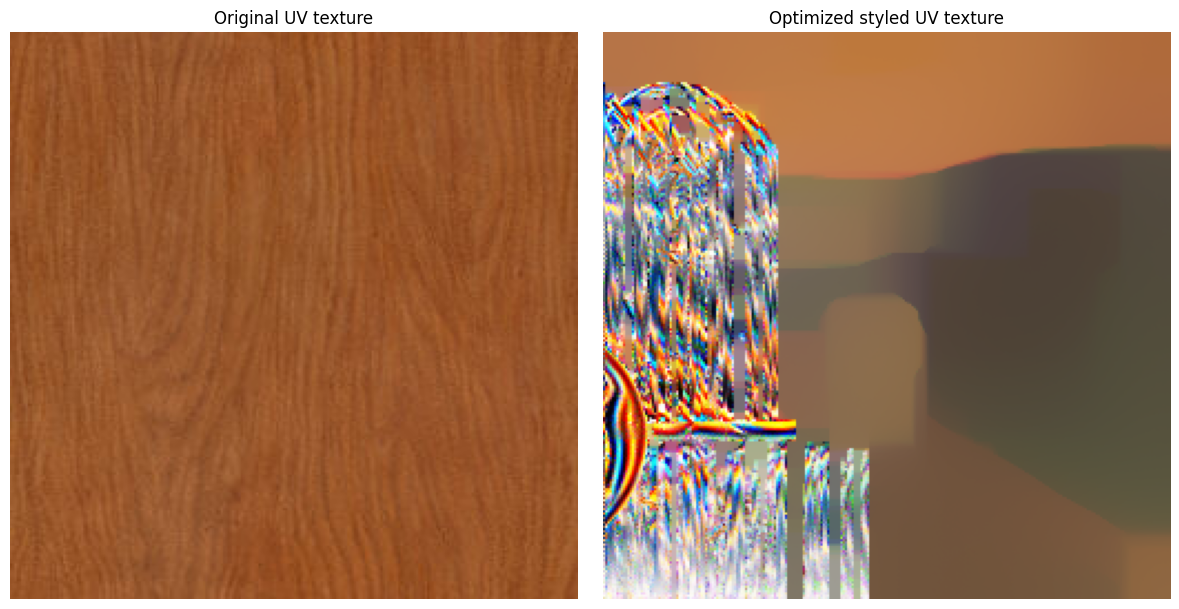

In [24]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(initial_texture.detach().cpu().clamp(0, 1).numpy())
plt.axis("off")
plt.title("Original UV texture")

plt.subplot(1, 2, 2)
plt.imshow(styled_texture.detach().cpu().clamp(0, 1).numpy())
plt.axis("off")
plt.title("Optimized styled UV texture")

plt.tight_layout()
plt.show()

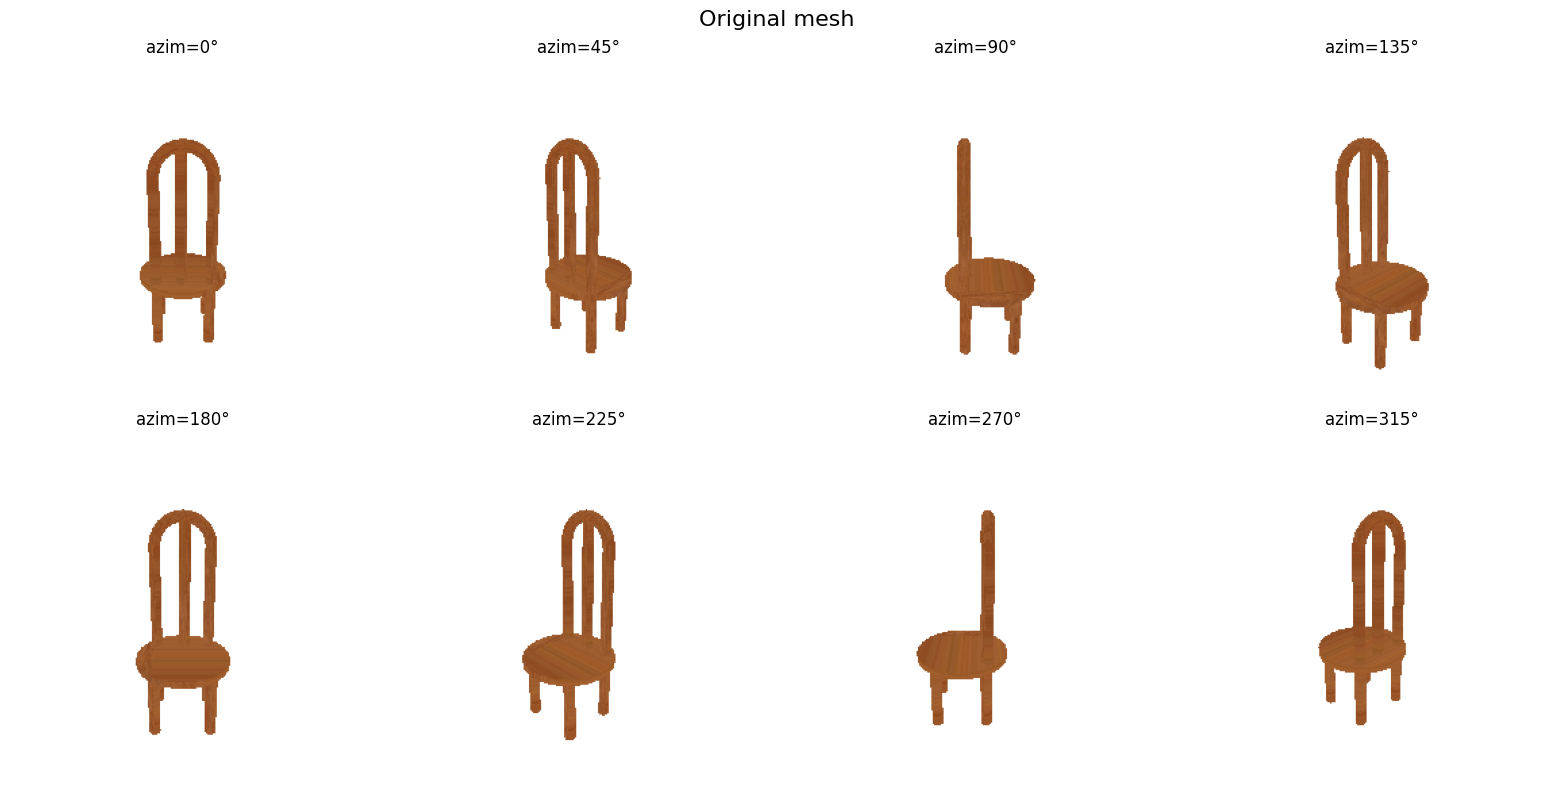

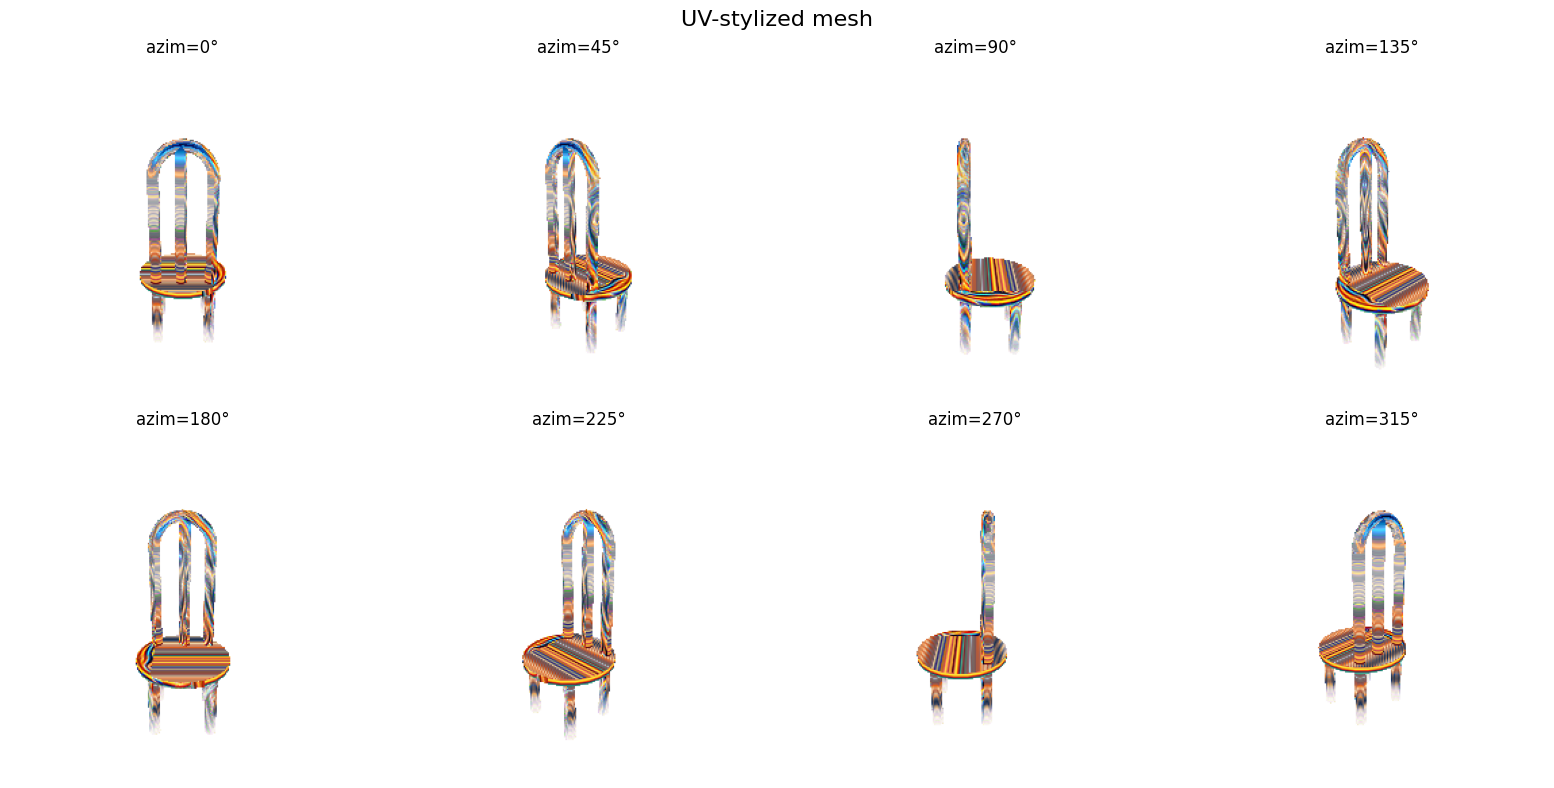

In [25]:
render_view_grid(
    mesh,
    initial_texture,
    EVAL_AZIMS,
    title="Original mesh",
    image_size=IMAGE_SIZE,
    elev=ELEV,
    dist=DIST,
)

render_view_grid(
    mesh,
    styled_texture,
    EVAL_AZIMS,
    title="UV-stylized mesh",
    image_size=IMAGE_SIZE,
    elev=ELEV,
    dist=DIST,
)

In [26]:
styled_texture_path = OUTPUT_DIR / "styled_uv_texture.png"

styled_arr = (
    styled_texture.detach()
    .cpu()
    .clamp(0, 1)
    .numpy() * 255
).astype(np.uint8)

Image.fromarray(styled_arr).save(styled_texture_path)

print("Saved styled texture to:", styled_texture_path)

Saved styled texture to: outputs_uv_texture_style/styled_uv_texture.png


In [28]:
final_render_dir = OUTPUT_DIR / "final_renders"
final_render_dir.mkdir(exist_ok=True)

for azim in EVAL_AZIMS:
    with torch.no_grad():
        img_original = render_mesh(
            mesh,
            initial_texture,
            azim=azim,
            elev=ELEV,
            dist=DIST,
            image_size=IMAGE_SIZE,
        )
        
        img_styled = render_mesh(
            mesh,
            styled_texture,
            azim=azim,
            elev=ELEV,
            dist=DIST,
            image_size=IMAGE_SIZE,
        )
    
    save_tensor_image(img_original, final_render_dir / f"original_azim_{azim}.png")
    save_tensor_image(img_styled, final_render_dir / f"uv_styled_azim_{azim}.png")

print("Saved renders to:", final_render_dir)

Saved renders to: outputs_uv_texture_style/final_renders


In [29]:
def optimize_2d_projection_style(
    content_img,
    style_targets,
    extractor,
    num_iters=200,
    lr=0.04,
    w_style=1500.0,
    w_tv=0.001,
):
    image_logits = nn.Parameter(
        to_logits(content_img.detach().clone())
    )
    
    optimizer_2d = torch.optim.Adam([image_logits], lr=lr)
    
    for it in range(num_iters):
        optimizer_2d.zero_grad()
        
        img = torch.sigmoid(image_logits)
        
        loss_style = style_loss_fn(img, style_targets, extractor)
        loss_tv = img_tv_loss(img)
        
        loss = (
            w_style * loss_style
            + w_tv * loss_tv
        )
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_([image_logits], max_norm=1.0)
        optimizer_2d.step()
    
    return torch.sigmoid(image_logits).detach()

In [30]:
baseline_azims = [0, 90, 180, 270]
baseline_results = []

baseline_dir = OUTPUT_DIR / "baseline_2d"
baseline_dir.mkdir(exist_ok=True)

for azim in tqdm(baseline_azims, desc="2D baseline"):
    with torch.no_grad():
        content_rgb, content_alpha = render_mesh_rgba(
            mesh,
            initial_texture,
            azim=azim,
            elev=ELEV,
            dist=DIST,
            image_size=IMAGE_SIZE,
        )
        
        content_crop = crop_foreground_tensor(
            content_rgb,
            content_alpha,
            out_size=IMAGE_SIZE,
            padding=35,
        )
    
    styled_2d = optimize_2d_projection_style(
        content_img=content_crop,
        style_targets=style_targets,
        extractor=vgg_extractor,
        num_iters=BASELINE_2D_ITERS,
        lr=BASELINE_2D_LR,
        w_style=W_STYLE,
        w_tv=W_TV,
    )
    
    baseline_results.append((azim, content_crop.detach(), styled_2d.detach()))
    
    save_tensor_image(content_crop, baseline_dir / f"baseline_content_azim_{azim}.png")
    save_tensor_image(styled_2d, baseline_dir / f"baseline_2d_styled_azim_{azim}.png")

print("Saved baseline 2D results to:", baseline_dir)

2D baseline: 100%|██████████| 4/4 [00:20<00:00,  5.22s/it]

Saved baseline 2D results to: outputs_uv_texture_style/baseline_2d


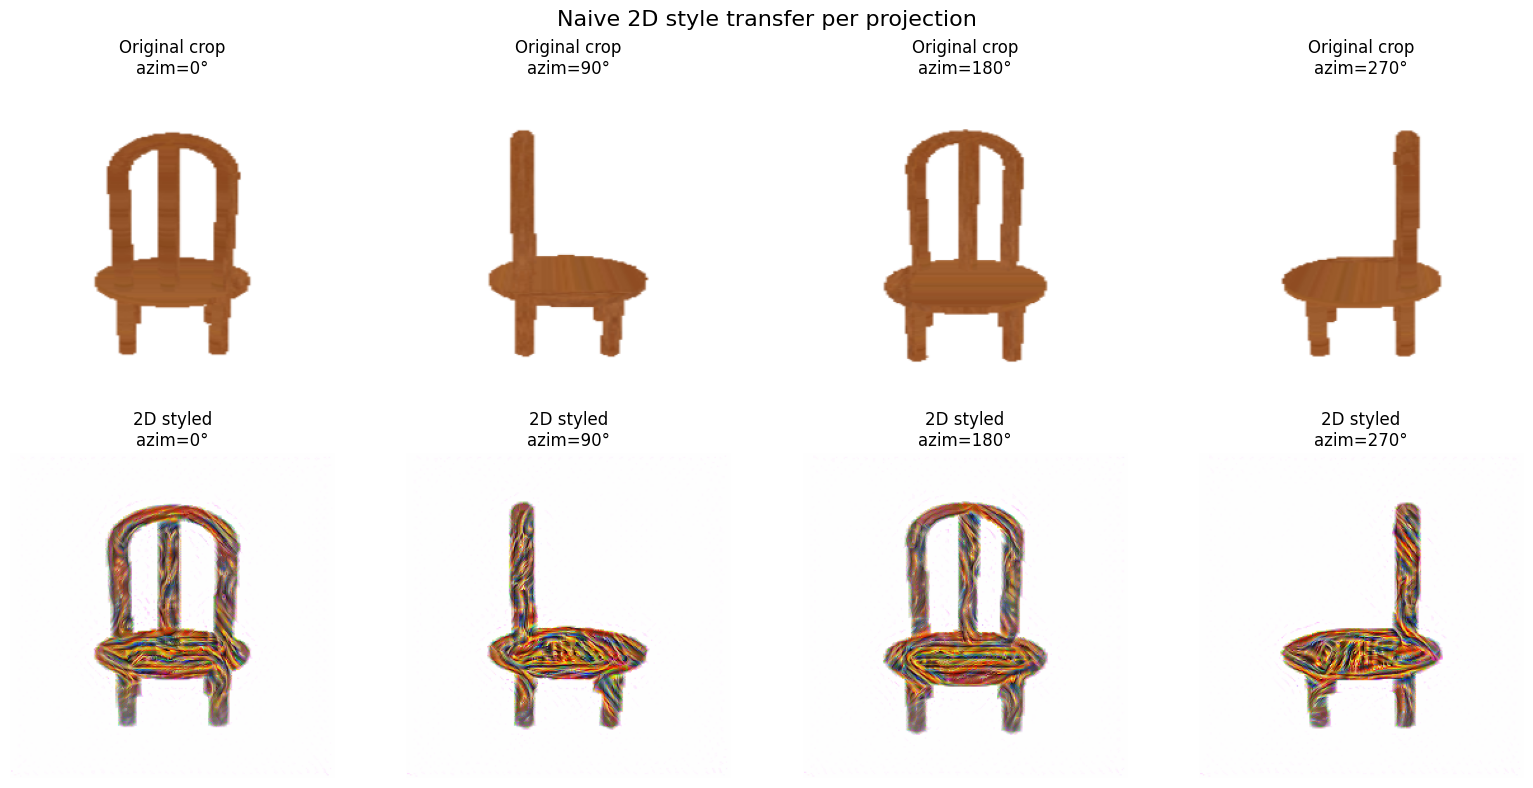

In [31]:
cols = len(baseline_results)
plt.figure(figsize=(4 * cols, 8))

for i, (azim, content_render, styled_2d) in enumerate(baseline_results):
    plt.subplot(2, cols, i + 1)
    plt.imshow(tensor_to_pil(content_render))
    plt.axis("off")
    plt.title(f"Original crop\nazim={azim}°")
    
    plt.subplot(2, cols, cols + i + 1)
    plt.imshow(tensor_to_pil(styled_2d))
    plt.axis("off")
    plt.title(f"2D styled\nazim={azim}°")

plt.suptitle("Naive 2D style transfer per projection", fontsize=16)
plt.tight_layout()
plt.show()

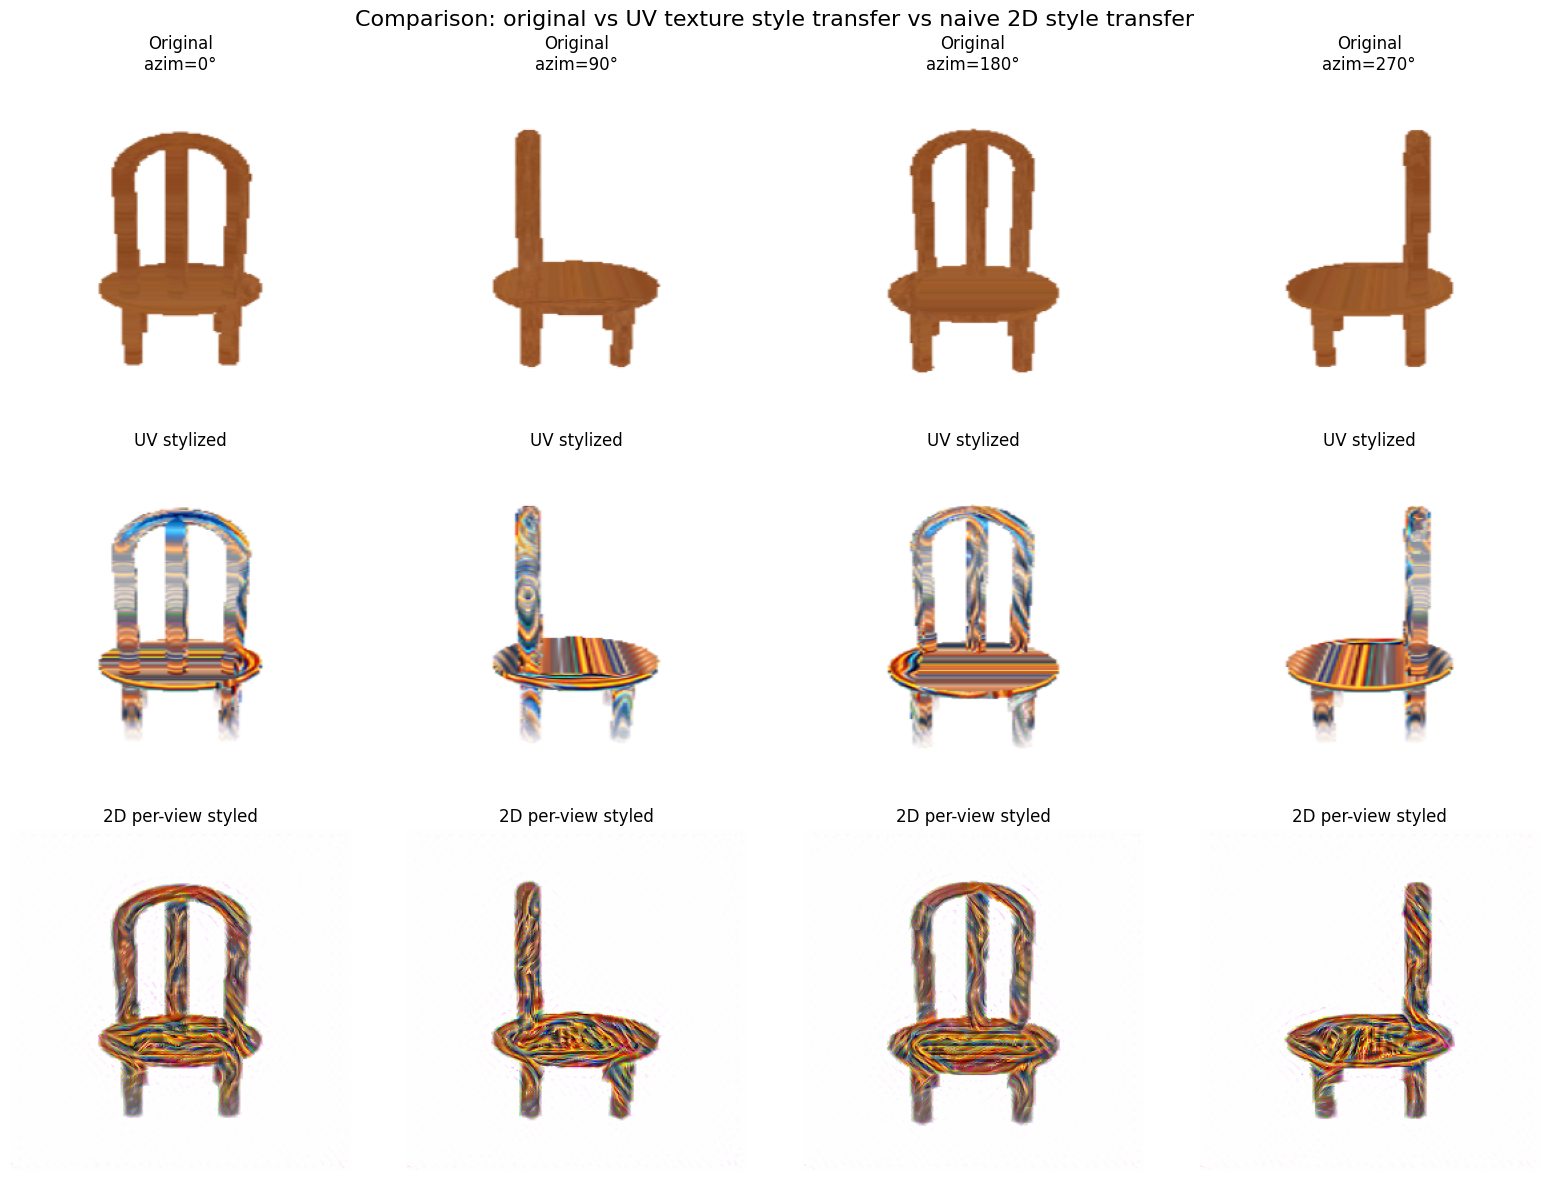

In [32]:
compare_azims = [0, 90, 180, 270]

plt.figure(figsize=(4 * len(compare_azims), 12))

for i, azim in enumerate(compare_azims):
    with torch.no_grad():
        original_rgb, original_alpha = render_mesh_rgba(
            mesh,
            initial_texture,
            azim=azim,
            elev=ELEV,
            dist=DIST,
            image_size=IMAGE_SIZE,
        )
        
        uv_styled_rgb, uv_styled_alpha = render_mesh_rgba(
            mesh,
            styled_texture,
            azim=azim,
            elev=ELEV,
            dist=DIST,
            image_size=IMAGE_SIZE,
        )
        
        original_crop = crop_foreground_tensor(
            original_rgb,
            original_alpha,
            out_size=IMAGE_SIZE,
            padding=35,
        )
        
        uv_styled_crop = crop_foreground_tensor(
            uv_styled_rgb,
            uv_styled_alpha,
            out_size=IMAGE_SIZE,
            padding=35,
        )
    
    baseline_2d = None
    
    for b_azim, _, b_img in baseline_results:
        if b_azim == azim:
            baseline_2d = b_img
            break
    
    plt.subplot(3, len(compare_azims), i + 1)
    plt.imshow(tensor_to_pil(original_crop))
    plt.axis("off")
    plt.title(f"Original\nazim={azim}°")
    
    plt.subplot(3, len(compare_azims), len(compare_azims) + i + 1)
    plt.imshow(tensor_to_pil(uv_styled_crop))
    plt.axis("off")
    plt.title("UV stylized")
    
    plt.subplot(3, len(compare_azims), 2 * len(compare_azims) + i + 1)
    if baseline_2d is not None:
        plt.imshow(tensor_to_pil(baseline_2d))
    plt.axis("off")
    plt.title("2D per-view styled")

plt.suptitle(
    "Comparison: original vs UV texture style transfer vs naive 2D style transfer",
    fontsize=16,
)

plt.tight_layout()
plt.show()

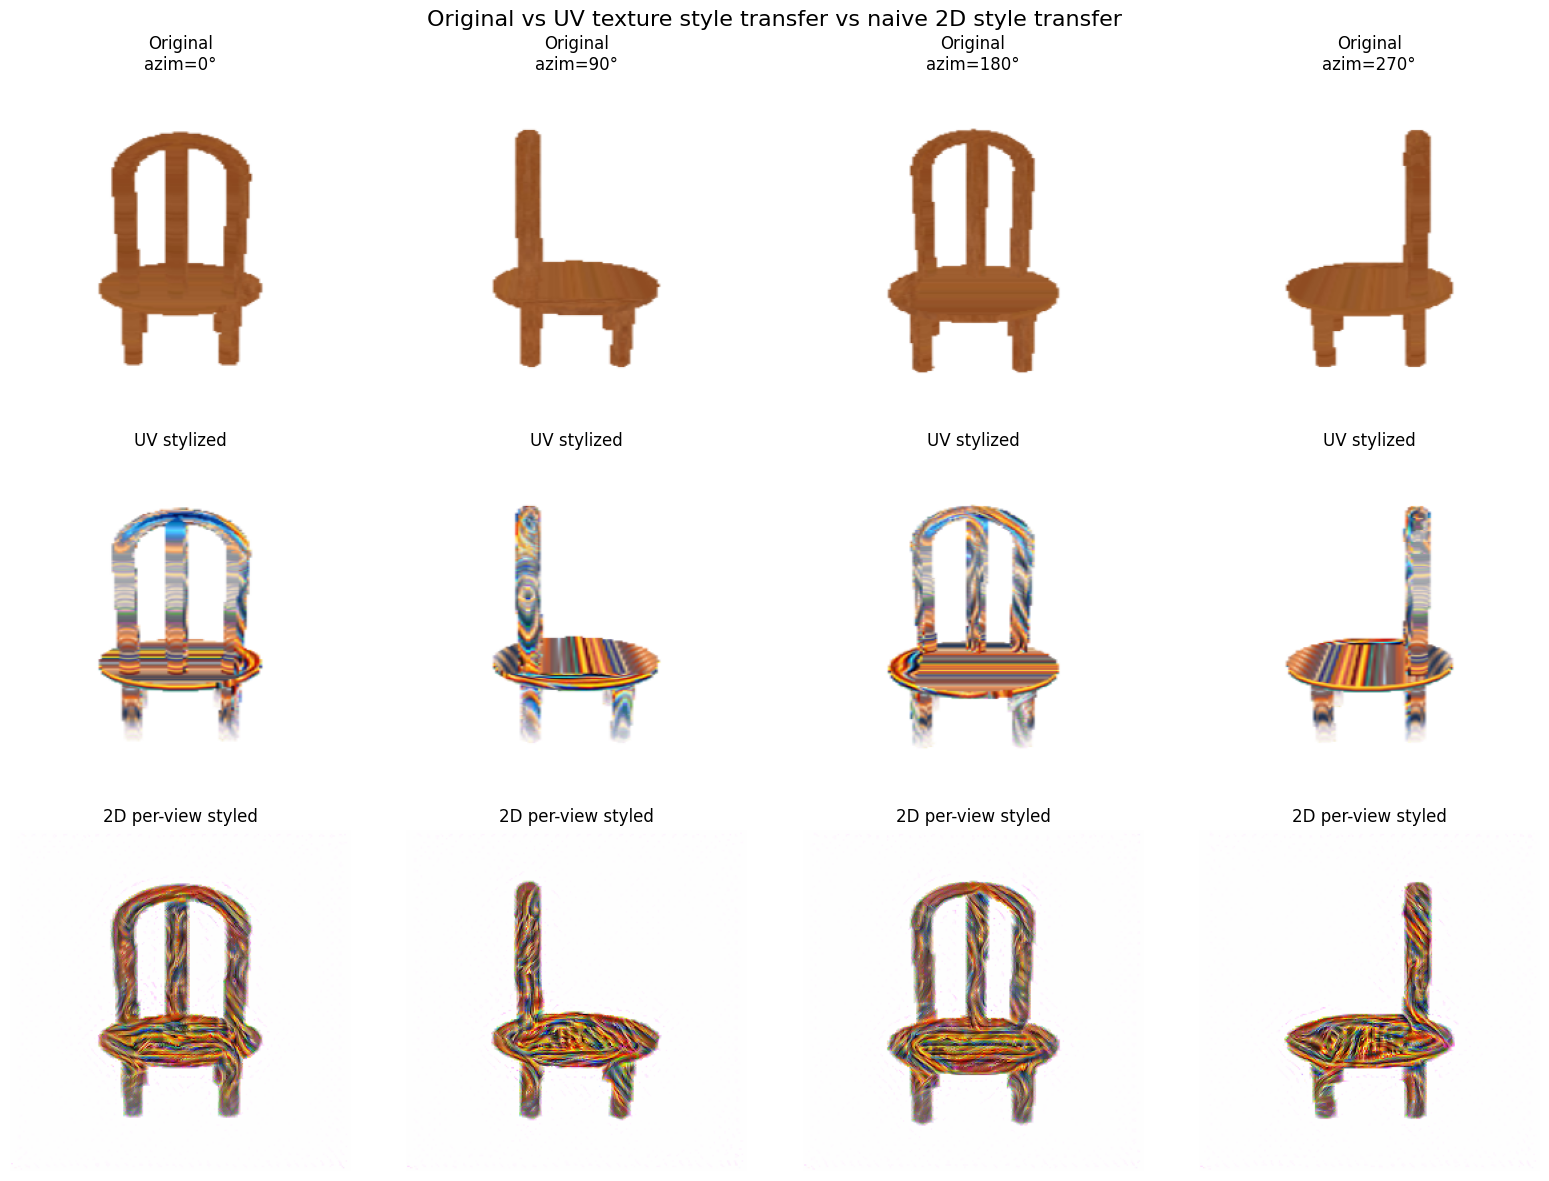

Saved final comparison to: outputs_uv_texture_style/final_comparison.png


In [33]:
compare_path = OUTPUT_DIR / "final_comparison.png"

compare_azims = [0, 90, 180, 270]

fig = plt.figure(figsize=(4 * len(compare_azims), 12))

for i, azim in enumerate(compare_azims):
    with torch.no_grad():
        original_rgb, original_alpha = render_mesh_rgba(
            mesh,
            initial_texture,
            azim=azim,
            elev=ELEV,
            dist=DIST,
            image_size=IMAGE_SIZE,
        )
        
        uv_styled_rgb, uv_styled_alpha = render_mesh_rgba(
            mesh,
            styled_texture,
            azim=azim,
            elev=ELEV,
            dist=DIST,
            image_size=IMAGE_SIZE,
        )
        
        original_crop = crop_foreground_tensor(
            original_rgb,
            original_alpha,
            out_size=IMAGE_SIZE,
            padding=35,
        )
        
        uv_styled_crop = crop_foreground_tensor(
            uv_styled_rgb,
            uv_styled_alpha,
            out_size=IMAGE_SIZE,
            padding=35,
        )
    
    baseline_2d = None
    
    for b_azim, _, b_img in baseline_results:
        if b_azim == azim:
            baseline_2d = b_img
            break
    
    plt.subplot(3, len(compare_azims), i + 1)
    plt.imshow(tensor_to_pil(original_crop))
    plt.axis("off")
    plt.title(f"Original\nazim={azim}°")
    
    plt.subplot(3, len(compare_azims), len(compare_azims) + i + 1)
    plt.imshow(tensor_to_pil(uv_styled_crop))
    plt.axis("off")
    plt.title("UV stylized")
    
    plt.subplot(3, len(compare_azims), 2 * len(compare_azims) + i + 1)
    if baseline_2d is not None:
        plt.imshow(tensor_to_pil(baseline_2d))
    plt.axis("off")
    plt.title("2D per-view styled")

plt.suptitle(
    "Original vs UV texture style transfer vs naive 2D style transfer",
    fontsize=16,
)

plt.tight_layout()
plt.savefig(compare_path, dpi=200)
plt.show()

print("Saved final comparison to:", compare_path)

In [34]:
export_texture_path = Path("data/chair_model/styled_texture.png")

styled_arr = (
    styled_texture.detach()
    .cpu()
    .clamp(0, 1)
    .numpy() * 255
).astype(np.uint8)

Image.fromarray(styled_arr).save(export_texture_path)

print("Exported styled texture to:", export_texture_path)

Exported styled texture to: data/chair_model/styled_texture.png
